===== DATASET =====
[[2.5 2.4]
 [0.5 0.7]
 [2.2 2.9]
 [1.9 2.2]
 [3.1 3. ]
 [2.3 2.7]
 [2.  1.6]
 [1.  1.1]
 [1.5 1.6]
 [1.1 0.9]]

===== MOYENNE =====
[1.81 1.91]

===== COVARIANCE =====
[[0.61655556 0.61544444]
 [0.61544444 0.71655556]]

===== VALEURS PROPRES =====
[0.0490834  1.28402771]

===== VECTEURS PROPRES =====
[[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]

===== DONNÉES PROJETÉES (1D) =====
[-0.82797019  1.77758033 -0.99219749 -0.27421042 -1.67580142 -0.9129491
  0.09910944  1.14457216  0.43804614  1.22382056]


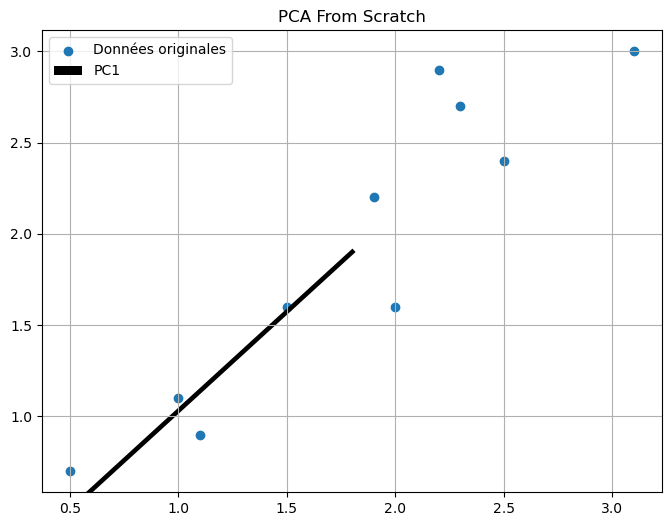

In [1]:
# ==========================================================
# PCA FROM SCRATCH EN PYTHON
# ==========================================================
#
# PCA signifie :
#
# Principal Component Analysis
#
# En français :
#
# Analyse en Composantes Principales
#
# ----------------------------------------------------------
# TYPE D'ALGORITHME :
# ----------------------------------------------------------
#
# Machine Learning non supervisé.
#
# Il n'utilise pas :
#
# -> variable cible y
#
# ----------------------------------------------------------
# OBJECTIF PRINCIPAL :
# ----------------------------------------------------------
#
# Réduire le nombre de dimensions
# d'un dataset.
#
# Exemple :
#
# 100 colonnes
# ↓
# 2 ou 3 colonnes importantes
#
# ----------------------------------------------------------
# POURQUOI UTILISER PCA ?
# ----------------------------------------------------------
#
# ✔ accélérer entraînement
# ✔ réduire mémoire
# ✔ supprimer bruit
# ✔ visualisation 2D/3D
# ✔ simplifier données
#
# ----------------------------------------------------------
# IDÉE PRINCIPALE :
# ----------------------------------------------------------
#
# PCA cherche :
#
# les directions où les données
# varient le plus.
#
# Ces directions sont appelées :
#
# composantes principales
#
# ----------------------------------------------------------
# EXEMPLE :
# ----------------------------------------------------------
#
# Si les données suivent
# une diagonale :
#
# PCA détecte cette direction.
#
# ----------------------------------------------------------
# ÉTAPES DU PCA :
# ----------------------------------------------------------
#
# 1. Standardisation
# 2. Calcul covariance
# 3. Valeurs propres
# 4. Vecteurs propres
# 5. Trier composantes
# 6. Projection données
#
# ==========================================================

# ==========================================================
# IMPORTATION DES LIBRARIES
# ==========================================================

# numpy :
# utilisé pour calculs mathématiques
import numpy as np

# matplotlib :
# utilisé pour visualisation graphique
import matplotlib.pyplot as plt

# ==========================================================
# 1. DATASET (2D SIMPLE)
# ==========================================================
#
# Dataset contenant :
#
# 10 points
# 2 dimensions
#
# Chaque ligne :
#
# [x1, x2]
#
# ==========================================================

X = np.array([

    [2.5, 2.4],

    [0.5, 0.7],

    [2.2, 2.9],

    [1.9, 2.2],

    [3.1, 3.0],

    [2.3, 2.7],

    [2.0, 1.6],

    [1.0, 1.1],

    [1.5, 1.6],

    [1.1, 0.9]
])

# ----------------------------------------------------------
# Affichage dataset
# ----------------------------------------------------------

print("===== DATASET =====")

print(X)

# ==========================================================
# 2. STANDARDISATION / CENTRAGE
# ==========================================================
#
# OBJECTIF :
# ----------------------------------------------------------
#
# Centrer les données autour de zéro.
#
# ----------------------------------------------------------
# POURQUOI ?
# ----------------------------------------------------------
#
# PCA fonctionne mieux
# avec données centrées.
#
# ----------------------------------------------------------
# FORMULE :
# ----------------------------------------------------------
#
# X_centered = X - moyenne
#
# ==========================================================

# ----------------------------------------------------------
# Calcul moyenne de chaque colonne
# ----------------------------------------------------------
#
# axis=0 :
# moyenne par colonne
#
# ----------------------------------------------------------

mean = np.mean(X, axis=0)

# ----------------------------------------------------------
# Centrage des données
# ----------------------------------------------------------
#
# Chaque point :
#
# point - moyenne
#
# ----------------------------------------------------------

X_centered = X - mean

# ----------------------------------------------------------
# Affichage moyenne
# ----------------------------------------------------------

print("\n===== MOYENNE =====")

print(mean)

# ==========================================================
# 3. MATRICE DE COVARIANCE
# ==========================================================
#
# OBJECTIF :
# ----------------------------------------------------------
#
# mesurer relation entre variables.
#
# ----------------------------------------------------------
# SI covariance positive :
# ----------------------------------------------------------
#
# variables augmentent ensemble
#
# ----------------------------------------------------------
# SI covariance négative :
# ----------------------------------------------------------
#
# une augmente
# l'autre diminue
#
# ----------------------------------------------------------
# GRANDE covariance :
# ----------------------------------------------------------
#
# forte relation
#
# ----------------------------------------------------------
# FORMULE :
# ----------------------------------------------------------
#
# Cov(X,Y) =
#
# Σ((x-mean_x)(y-mean_y))
# ------------------------
#         n-1
#
# ==========================================================

# ----------------------------------------------------------
# .T :
# transpose matrice
#
# np.cov :
# calcul covariance
# ----------------------------------------------------------

cov_matrix = np.cov(X_centered.T)

# ----------------------------------------------------------
# Affichage matrice covariance
# ----------------------------------------------------------

print("\n===== COVARIANCE =====")

print(cov_matrix)

# ==========================================================
# 4. VALEURS PROPRES / VECTEURS PROPRES
# ==========================================================
#
# OBJECTIF :
# ----------------------------------------------------------
#
# Trouver directions principales
# des données.
#
# ----------------------------------------------------------
# VALEURS PROPRES (eigenvalues)
# ----------------------------------------------------------
#
# indiquent :
#
# importance de chaque direction
#
# grande valeur propre :
# -> direction importante
#
# ----------------------------------------------------------
# VECTEURS PROPRES (eigenvectors)
# ----------------------------------------------------------
#
# indiquent :
#
# direction des composantes
#
# ==========================================================

# ----------------------------------------------------------
# np.linalg.eig :
# calcul valeurs/vecteurs propres
# ----------------------------------------------------------

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# ----------------------------------------------------------
# Affichage valeurs propres
# ----------------------------------------------------------

print("\n===== VALEURS PROPRES =====")

print(eigenvalues)

# ----------------------------------------------------------
# Affichage vecteurs propres
# ----------------------------------------------------------

print("\n===== VECTEURS PROPRES =====")

print(eigenvectors)

# ==========================================================
# 5. TRI DES COMPOSANTES
# ==========================================================
#
# OBJECTIF :
# ----------------------------------------------------------
#
# Classer composantes
# de la plus importante
# vers la moins importante.
#
# ----------------------------------------------------------
# argsort :
# ----------------------------------------------------------
#
# retourne indices triés
#
# [::-1]
#
# inverse ordre :
# décroissant
#
# ==========================================================

# ----------------------------------------------------------
# Indices triés décroissants
# ----------------------------------------------------------

sorted_idx = np.argsort(eigenvalues)[::-1]

# ----------------------------------------------------------
# Trier valeurs propres
# ----------------------------------------------------------

eigenvalues = eigenvalues[sorted_idx]

# ----------------------------------------------------------
# Trier vecteurs propres
# ----------------------------------------------------------

eigenvectors = eigenvectors[:, sorted_idx]

# ==========================================================
# 6. PROJECTION SUR 1 DIMENSION
# ==========================================================
#
# OBJECTIF :
# ----------------------------------------------------------
#
# réduire données :
#
# 2D
# ↓
# 1D
#
# ----------------------------------------------------------
# On garde :
# ----------------------------------------------------------
#
# la composante principale
#
# c'est-à-dire :
#
# celle avec plus grande variance
#
# ==========================================================

# ----------------------------------------------------------
# Première composante principale
# ----------------------------------------------------------
#
# eigenvectors[:,0]
#
# -> première colonne
#
# ----------------------------------------------------------

W = eigenvectors[:, 0]

# ==========================================================
# PROJECTION
# ==========================================================
#
# dot product :
#
# projeter données
# sur nouvelle direction
#
# ----------------------------------------------------------
# FORMULE :
# ----------------------------------------------------------
#
# X_pca = X_centered × W
#
# ==========================================================

X_pca = X_centered.dot(W)

# ----------------------------------------------------------
# Affichage nouvelles données
# ----------------------------------------------------------

print("\n===== DONNÉES PROJETÉES (1D) =====")

print(X_pca)

# ==========================================================
# 7. VISUALISATION
# ==========================================================

# ----------------------------------------------------------
# Taille figure
# ----------------------------------------------------------

plt.figure(figsize=(8, 6))

# ==========================================================
# DONNÉES ORIGINALES
# ==========================================================
#
# scatter :
# affichage des points
#
# ==========================================================

plt.scatter(

    X[:, 0],

    X[:, 1],

    label="Données originales"
)

# ==========================================================
# COMPOSANTE PRINCIPALE
# ==========================================================
#
# origin :
# point de départ flèche
#
# ==========================================================

origin = mean

# ----------------------------------------------------------
# Agrandir vecteur pour affichage
# ----------------------------------------------------------

pc1 = eigenvectors[:, 0] * 3

# ==========================================================
# QUIVER
# ==========================================================
#
# affiche une flèche.
#
# Cette flèche représente :
#
# la direction principale des données.
#
# ==========================================================

plt.quiver(

    origin[0],

    origin[1],

    pc1[0],

    pc1[1],

    angles='xy',

    scale_units='xy',

    scale=1,

    label="PC1"
)

# ----------------------------------------------------------
# Titre graphique
# ----------------------------------------------------------

plt.title("PCA From Scratch")

# ----------------------------------------------------------
# Afficher légende
# ----------------------------------------------------------

plt.legend()

# ----------------------------------------------------------
# Afficher grille
# ----------------------------------------------------------

plt.grid()

# ----------------------------------------------------------
# Afficher graphique
# ----------------------------------------------------------

plt.show()